In [1]:
import pandas as pd
import seaborn as sns

In [2]:
path = '/home/ls/toozig/gonen-lab/users/toozig/projects/dsd-viz/bed_file_merger/results/mm10_to_hg38_files'
converted = 'results/mm10_to_hg38_files/liftOveroutput/liftover_mm10_to_hg38_peaks.bed'
original  = '/home/ls/toozig/gonen-lab/users/toozig/projects/dsd-viz/bed_file_merger/results/mm10_merged_peaks_030925.bed'

In [3]:
from typing import List, Set
import re
def shorten_developmental_id(long_id: str) -> str:
    """
    Converts long developmental ID string to shortened format.
    
    Example:
    Input: "E13.5.XY.31285_E12.5.XY.35117_E15.5.XX.19270_E11.5.XX.15939_E13.5.XX.25880_E15.5.XY.28022_E12.5.XX.9404_E11.5.XY.9326"
    Output: "XY11.12.13.15XX11.12.13.15"
    
    Args:
        long_id: Long ID string with format E<stage>.<substage>.<sex>.<number>_...
        
    Returns:
        Shortened ID with format <sex><stages><sex><stages>...
    """
    # Pattern to match: E<stage>.<substage>.<sex>.<number>
    pattern = r'E(\d+\.?\d*)\.([XY]{2})\.\d+'
    
    # Find all matches
    matches = re.findall(pattern, long_id)
    
    if not matches:
        return long_id  # Return original if no matches found
    
    # Separate XY and XX stages
    xy_stages: Set[str] = set()
    xx_stages: Set[str] = set()
    
    for stage, sex in matches:
        if sex == 'XY':
            xy_stages.add(stage)
        elif sex == 'XX':
            xx_stages.add(stage)
    
    # Sort stages numerically
    def sort_stages(stages: Set[str]) -> List[str]:
        return sorted(stages, key=lambda x: float(x))
    
    # Build result string
    result = ""
    
    if xy_stages:
        sorted_xy = sort_stages(xy_stages)
        result += "XY" + ".".join(sorted_xy)
    
    if xx_stages:
        sorted_xx = sort_stages(xx_stages)
        result += "XX" + ".".join(sorted_xx)
    
    return result

In [4]:
# Load the bed files into dataframes
original_df = pd.read_csv(original, sep='\t', header=None, names=['chr', 'start', 'end', 'ID'])
original_df['original_size'] = original_df['end'] - original_df['start']
converted_df = pd.read_csv(converted, sep='\t', header=None, names=['chr', 'start', 'end', 'ID', 'n_multiple'])
converted_df['converted_size'] = converted_df['end'] - converted_df['start']
original_df.head()
converted_df['new_id'] = converted_df['ID'].apply(shorten_developmental_id) + '.' + converted_df.index.astype(str)
converted_df

,chr,start,end,ID,n_multiple,converted_size,new_id
0,chr8,55609563,55610377,"E15.5.XX.1,E13.5.XX.1",1,814,XX13.5.15.5.0
1,chr8,55593213,55593597,E15.5.XY.1,1,384,XY15.5.1
2,chr8,55591903,55592360,"E13.5.XX.2,E15.5.XY.2,E15.5.XX.2,E11.5.XX.1",1,457,XY15.5XX11.5.13.5.15.5.2
3,chr8,55580923,55581191,E15.5.XY.3,1,268,XY15.5.3
4,chr8,55527051,55527871,"E13.5.XX.4,E13.5.XY.1,E12.5.XY.2,E15.5.XY.4,E1...",1,820,XY11.5.12.5.13.5.15.5XX11.5.13.5.15.5.4
...,...,...,...,...,...,...,...
88429,chrX,24054686,24055211,"E12.5.XY.83411,E15.5.XY.67042,E13.5.XY.74066,E...",1,525,XY11.5.12.5.13.5.15.5.88429
88430,chrY,13479112,13480068,"E13.5.XY.74068,E15.5.XY.67044,E12.5.XY.83414,E...",1,956,XY11.5.12.5.13.5.15.5.88430
88431,chrY,12904893,12905250,"E12.5.XY.83416,E13.5.XY.74070,E15.5.XY.67046,E...",1,357,XY11.5.12.5.13.5.15.5.88431
88432,chrY,12811599,12811793,E15.5.XY.67047,1,194,XY15.5.88432


In [5]:


comparison_df = pd.merge(original_df[['ID', 'original_size']], converted_df[['ID', 'converted_size']], on='ID')

comparison_df['diffrence'] = comparison_df.original_size - comparison_df.converted_size

comparison_df.head()
faild_to_convert = original_df.shape[0] - converted_df.shape[0]


REL_TOL = 0.25   # 10%
ABS_TOL = 1000   # bp
minimal_size = original_df['original_size'].min()
minimal_size = max(minimal_size - (minimal_size * REL_TOL), 100)
filter_ids = converted_df[converted_df.n_multiple > 1].ID
def filter_peak(row):
    original = int(row['original_size'])
    converted = int(row['converted_size'])
    original_10pct = original * REL_TOL
    abs_diff = abs(original - converted)
    pct_diff = abs_diff / original
    # check if the difference is within 10% of the original size
    # check if the difference is within 1000 bp

    abs_diff_filter = abs_diff <= ABS_TOL
    size_filter = converted >= minimal_size
    return   abs_diff_filter and size_filter

# filter according tof the filter_peak function
comparison_df['passed_size_filter'] = comparison_df.apply(filter_peak, axis=1)
comparison_df['passed_multiple_filter'] =  ~comparison_df.ID.isin(filter_ids)
comparison_df

,ID,original_size,converted_size,diffrence,passed_size_filter,passed_multiple_filter
0,"E15.5.XX.1,E13.5.XX.1",817,814,3,True,True
1,E15.5.XY.1,333,384,-51,True,True
2,"E13.5.XX.2,E15.5.XY.2,E15.5.XX.2,E11.5.XX.1",684,457,227,True,True
3,E15.5.XY.3,237,268,-31,True,True
4,"E13.5.XX.4,E13.5.XY.1,E12.5.XY.2,E15.5.XY.4,E1...",925,820,105,True,True
...,...,...,...,...,...,...
88429,"E12.5.XY.83411,E15.5.XY.67042,E13.5.XY.74066,E...",1051,525,526,True,True
88430,"E13.5.XY.74068,E15.5.XY.67044,E12.5.XY.83414,E...",1426,956,470,True,True
88431,"E12.5.XY.83416,E13.5.XY.74070,E15.5.XY.67046,E...",1506,357,1149,False,True
88432,E15.5.XY.67047,245,194,51,True,True


In [6]:
minimal_size

141.0

In [7]:

comparison_df['passed_multiple_filter'] =  ~comparison_df.ID.isin(filter_ids)
comparison_df

,ID,original_size,converted_size,diffrence,passed_size_filter,passed_multiple_filter
0,"E15.5.XX.1,E13.5.XX.1",817,814,3,True,True
1,E15.5.XY.1,333,384,-51,True,True
2,"E13.5.XX.2,E15.5.XY.2,E15.5.XX.2,E11.5.XX.1",684,457,227,True,True
3,E15.5.XY.3,237,268,-31,True,True
4,"E13.5.XX.4,E13.5.XY.1,E12.5.XY.2,E15.5.XY.4,E1...",925,820,105,True,True
...,...,...,...,...,...,...
88429,"E12.5.XY.83411,E15.5.XY.67042,E13.5.XY.74066,E...",1051,525,526,True,True
88430,"E13.5.XY.74068,E15.5.XY.67044,E12.5.XY.83414,E...",1426,956,470,True,True
88431,"E12.5.XY.83416,E13.5.XY.74070,E15.5.XY.67046,E...",1506,357,1149,False,True
88432,E15.5.XY.67047,245,194,51,True,True


In [8]:


# Calculate filtering statistics
size_filter_passed = comparison_df['passed_size_filter'].sum()
size_filter_failed = len(comparison_df) - size_filter_passed
multiple_filter_passed = comparison_df['passed_multiple_filter'].sum()
multiple_filter_failed = len(comparison_df) - multiple_filter_passed
both_filters_passed = (comparison_df['passed_size_filter'] & comparison_df['passed_multiple_filter']).sum()

# Create statistics dictionaries
peak_filtering_stats = {
    'metric': ['Total original peaks', 'Total converted peaks', 'Failed to convert'],
    'count': [original_df.shape[0], converted_df.shape[0], faild_to_convert],
    'percentage': [100.0, converted_df.shape[0]/original_df.shape[0]*100, faild_to_convert/original_df.shape[0]*100]
}

size_filter_stats = {
    'metric': ['Passed size filter', 'Failed size filter'],
    'count': [size_filter_passed, size_filter_failed],
    'percentage': [size_filter_passed/len(comparison_df)*100, size_filter_failed/len(comparison_df)*100]
}

multiple_filter_stats = {
    'metric': ['Passed multiple mapping filter', 'Failed multiple mapping filter'],
    'count': [multiple_filter_passed, multiple_filter_failed],
    'percentage': [multiple_filter_passed/len(comparison_df)*100, multiple_filter_failed/len(comparison_df)*100]
}

combined_filter_stats = {
    'metric': ['Passed both filters', 'Failed at least one filter', 'Overall pass rate', 'Final conversion success rate'],
    'count': [both_filters_passed, len(comparison_df) - both_filters_passed, both_filters_passed, both_filters_passed],
    'percentage': [both_filters_passed/len(comparison_df)*100, (len(comparison_df) - both_filters_passed)/len(comparison_df)*100, 
                  both_filters_passed/len(comparison_df)*100, both_filters_passed/original_df.shape[0]*100]
}

# Convert to DataFrames and save as CSV
peak_filtering_df = pd.DataFrame(peak_filtering_stats)
size_filter_df = pd.DataFrame(size_filter_stats)
multiple_filter_df = pd.DataFrame(multiple_filter_stats)
combined_filter_df = pd.DataFrame(combined_filter_stats)

# Add category column for identification
peak_filtering_df['category'] = 'Peak Filtering'
size_filter_df['category'] = 'Size Filter'
multiple_filter_df['category'] = 'Multiple Mapping Filter'
combined_filter_df['category'] = 'Combined Filter'

# Combine all statistics into one DataFrame
all_stats_df = pd.concat([peak_filtering_df, size_filter_df, multiple_filter_df, combined_filter_df], ignore_index=True)
filtered_df = comparison_df[comparison_df['passed_size_filter'] & comparison_df['passed_multiple_filter']]


# merge each df with the converted df
comparison_df = pd.merge(converted_df[['chr', 'start', 'end', 'ID', 'new_id']], comparison_df, on='ID', how='right',)
filtered_df = pd.merge(converted_df[['chr', 'start', 'end', 'ID', 'new_id']], filtered_df, on='ID', how='right')


In [9]:

# sort all df by chrom and start
comparison_df = comparison_df.sort_values(by=['chr', 'start'])
filtered_df = filtered_df.sort_values(by=['chr', 'start'])
converted_df = converted_df.sort_values(by=['chr', 'start'])

# remove ID col and rename new_id to ID
comparison_df = comparison_df.drop(columns=['ID'])
comparison_df = comparison_df.rename(columns={'new_id': 'ID'})
filtered_df = filtered_df.drop(columns=['ID'])
filtered_df = filtered_df.rename(columns={'new_id': 'ID'})

# Save to CSV
dir_path = 'results/mm10_to_hg38_files/liftOverFilteration'
# Save to Excel with multiple tabs
excel_file_path = f'{dir_path}/mm10_to_hg38_analysis_results.xlsx'
with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
    filtered_df.to_excel(writer, sheet_name='Filtered_Peaks', index=False)
    comparison_df.to_excel(writer, sheet_name='All_Peak', index=False)
    all_stats_df.to_excel(writer, sheet_name='All_Statistics', index=False)


# Print the statistics for verification
print("=== Peak Filtering Results ===")
print(f"Total original peaks: {original_df.shape[0]:,}")
print(f"Total converted peaks: {converted_df.shape[0]:,}")
print(f"Failed to convert: {faild_to_convert:,}")
print()

print("=== Size Filter Results ===")
print(f"Passed size filter: {size_filter_passed:,}")
print(f"Failed size filter: {size_filter_failed:,}")
print(f"Size filter pass rate: {size_filter_passed/len(comparison_df)*100:.1f}%")
print()

print("=== Multiple Mapping Filter Results ===")
print(f"Passed multiple mapping filter: {multiple_filter_passed:,}")
print(f"Failed multiple mapping filter: {multiple_filter_failed:,}")
print(f"Multiple mapping filter pass rate: {multiple_filter_passed/len(comparison_df)*100:.1f}%")
print()

print("=== Combined Filter Results ===")
print(f"Passed both filters: {both_filters_passed:,}")
print(f"Failed at least one filter: {len(comparison_df) - both_filters_passed:,}")
print(f"Overall pass rate: {both_filters_passed/len(comparison_df)*100:.1f}%")
print(f"Final conversion success rate: {both_filters_passed/original_df.shape[0]*100:.1f}%")


print(f"\nStatistics saved to: mm10_to_hg38_conversion_statistics.csv")

# wrtie  all the stats to a csv 


=== Peak Filtering Results ===
Total original peaks: 107,837
Total converted peaks: 88,434
Failed to convert: 19,403

=== Size Filter Results ===
Passed size filter: 82,571
Failed size filter: 5,863
Size filter pass rate: 90.9%

=== Multiple Mapping Filter Results ===
Passed multiple mapping filter: 86,349
Failed multiple mapping filter: 2,085
Multiple mapping filter pass rate: 95.1%

=== Combined Filter Results ===
Passed both filters: 81,324
Failed at least one filter: 9,484
Overall pass rate: 89.6%
Final conversion success rate: 75.4%

Statistics saved to: mm10_to_hg38_conversion_statistics.csv


In [10]:

bed_filtered_df = filtered_df[['chr', 'start', 'end', 'ID']]
# bed_filtered_df.ID = bed_filtered_df.ID.str.replace(',', '_')
bed_filtered_df.to_csv(f'{dir_path}/mm10_to_hg38_filtered_070925.bed', sep='\t', index=False, header=False)


In [11]:
filtered_df.converted_size.min()

141

/tmp/ipykernel_3847489/826420629.py:10: UserWarning: Only one of 'bins' and 'norm' arguments can be supplied, ignoring bins='log'
  hex_plot = ax.hexbin(filtered_df['original_size'], filtered_df['converted_size'],


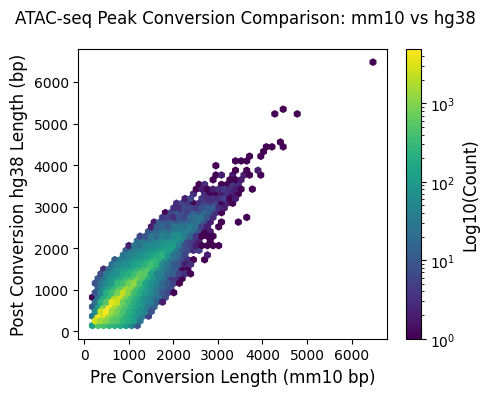

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(5, 4))
fig.suptitle('ATAC-seq Peak Conversion Comparison: mm10 vs hg38', fontsize=12)

# Create a hex plot using matplotlib to represent density
hex_plot = ax.hexbin(filtered_df['original_size'], filtered_df['converted_size'], 
                     gridsize=50, bins='log', cmap='viridis', 
                     norm=LogNorm())  # Use log normalization for better density representation

ax.set_xlabel('Pre Conversion Length (mm10 bp)', fontsize=12)
ax.set_ylabel('Post Conversion hg38 Length (bp)', fontsize=12)

# Add a colorbar to the hex plot with density label
cbar = plt.colorbar(hex_plot, ax=ax)
cbar.set_label('Log10(Count)', fontsize=12)

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig(f'{dir_path}/mm10_hg38_length_comparison_hexplot.svg')
plt.savefig(f'{dir_path}/mm10_hg38_length_comparison_hexplot.png')
plt.show()